In [1]:
%load_ext autoreload
%autoreload 2
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion

### Request HPC Resources

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='80GB',
    walltime='8:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=4)
cluster.wait_for_workers(4)
client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=75G
#SBATCH -t 8:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/bin/python -m distributed.cli.dask_worker tcp://172.16.3.77:35401 --name dummy-name --nthreads 36 --memory-limit 74.51GiB --nanny --death-timeout 60 --interface ib0



<Client: 'tcp://172.16.3.77:35401' processes=4 threads=144, memory=298.04 GiB>

### Load in data

In [3]:
# Key water mass transformation budget terms

budget_terms = [
    # 'Eulerian_tendency', 'advection', 'diffusion', 
            'boundary_fluxes', #'convergent_mass_transport', 
           # 'mass_tendency', 'mass_source', 'spurious_numerical_mixing', 
           "surface_exchange_flux", "bottom_flux", "frazil_ice", 
            "surface_ocean_flux_advective_negative_rhs"]

other_budget_terms = ["surface_ocean_flux_advective_negative_rhs_heat", 
                     "surface_ocean_flux_advective_negative_rhs_salt", 
                     "surface_exchange_flux_heat", 
                     "surface_exchange_flux_salt", 
                     "frazil_ice_heat", 
                     "bottom_flux_heat",
                     "boundary_fluxes", 
                     # "mass_tendency", 
                     # "diffusion_heat", 
                     # "diffusion_salt",
                     # "spurious_numerical_mixing",
                     # "convergent_mass_transport"
                     ]
budget_terms= sorted(list(set(budget_terms) | set(other_budget_terms)))

In [4]:
decomp_budget_terms = ["surface_exchange_flux_advective_evaporation_salt", 
                    "surface_exchange_flux_advective_rain_and_ice_salt",
                    "surface_exchange_flux_advective_snow_salt",
                    "surface_exchange_flux_advective_rivers_salt", 
                    "surface_exchange_flux_advective_icebergs_salt",
                    "surface_exchange_flux_advective_virtual_precip_restoring_salt",
                    "surface_exchange_flux_advective_sea_ice_salt",
                    "surface_exchange_flux_nonadvective_basal_salt",
                    "surface_exchange_flux_nonadvective_longwave_heat", 
                    "surface_exchange_flux_nonadvective_shortwave_heat",
                    "surface_exchange_flux_nonadvective_sensible_heat",
                    "surface_exchange_flux_nonadvective_latent_heat", 
                    "surface_exchange_flux_advective_mass_transfer_heat"]

In [5]:
def decompose_boundary_fluxes(ds): 
    ds["boundary_fluxes_heat"] = ds["surface_ocean_flux_advective_negative_rhs_heat"] +\
                             ds["surface_exchange_flux_heat"] +\
                             ds["frazil_ice_heat"] + ds["bottom_flux_heat"]

    ds["boundary_fluxes_salt"] = ds["surface_ocean_flux_advective_negative_rhs_salt"] +\
                                     ds["surface_exchange_flux_salt"]

    ds["surface_boundary_fluxes_salt"] = 1 * ds["boundary_fluxes_salt"]
    ds["surface_boundary_fluxes_heat"] = ds["boundary_fluxes_heat"] - ds["bottom_flux_heat"]

In [6]:
from tqdm import tqdm

datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budgets_sigma2_1p5/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

wmts = []

for (t, file) in enumerate(tqdm(datafiles)): 
    # print(file)
    ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")
    ds = ds.fillna(0.)

    ds['mask'] = (
        (ds['geolat'] <= -50) * 
        (ds["deptho"] <= 1150)
    )

    grid = CM4Xutils.ds_to_grid(ds, Zprefix = "sigma2")
    grid._ds = grid._ds.assign_coords({
        "sigma2_l_target": grid._ds['sigma2_l'].rename({"sigma2_l":"sigma2_l_target"}),
        "sigma2_i_target": grid._ds['sigma2_i'].rename({"sigma2_i":"sigma2_i_target"}),
    })
    grid = xwmt.add_gridcoords(
        grid,
        {"Z_target": {"center": "sigma2_l_target", "outer": "sigma2_i_target"}},
        {"Z_target": "extend"}
    )
    regions = MaskRegions(ds.mask, grid).region_dict
    antarctic = regions[0] #there are more in this list if there are multiple contours 
    region = GriddedRegion("antarctic", antarctic.lons, antarctic.lats, grid, 
                           ij=(antarctic.i, antarctic.j))

    # .sel(sigma2_l_target = slice(36.2, None))
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)

        budgets_dict = xbudget.load_yaml("MOM6_AABW_updated.yaml")

        xbudget.collect_budgets(grid, budgets_dict)
        
        wmb = xwmb.WaterMassBudget(
            grid,
            budgets_dict, 
            region
        ) #if region not passed, the whole globe is taken
        wmb.mass_budget("sigma2", greater_than=True, default_bins=False, 
                        integrate=False, along_section=False)
        
        wmt = wmb.wmt[budget_terms].sel(sigma2_l_target = slice(36.25, 37.5), yh = slice(None, 50))
        wmt_yearly = wmt.groupby("time.year").mean("time").compute()
        
        decompose_boundary_fluxes(wmt_yearly)
        
        wmb_decomp = xwmb.WaterMassBudget(
            grid,
            budgets_dict, 
            region, 
            decompose=["surface_exchange_flux", "nonadvective", "advective"]
        ) #if region not passed, the whole globe is taken
        
        wmb_decomp.mass_budget("sigma2", greater_than=True, default_bins=False, 
                        integrate=False, along_section=False)
        
        wmt_decomp = wmb_decomp.wmt[decomp_budget_terms].sel(sigma2_l_target = slice(36.25, 37.5), yh = slice(None, 50))
        wmt_decomp_yearly = wmt_decomp.groupby("time.year").mean("time").compute()
        
        wmts += [1 * xr.merge([wmt_decomp_yearly, wmt_yearly])]

wmts_ds = xr.concat(wmts, dim = "year")
print(f"Dataset size: {wmts_ds.nbytes / (1024**3):.2f} GB")
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
wmts_ds.to_netcdf(savedir + f"Southern_Ocean_DSW_1100m_WMT_Surface_Fluxes_sigma_slice.nc")

100%|██████████| 50/50 [1:48:44<00:00, 130.49s/it]


Dataset size: 38.30 GB


In [ ]:
wmts_ds

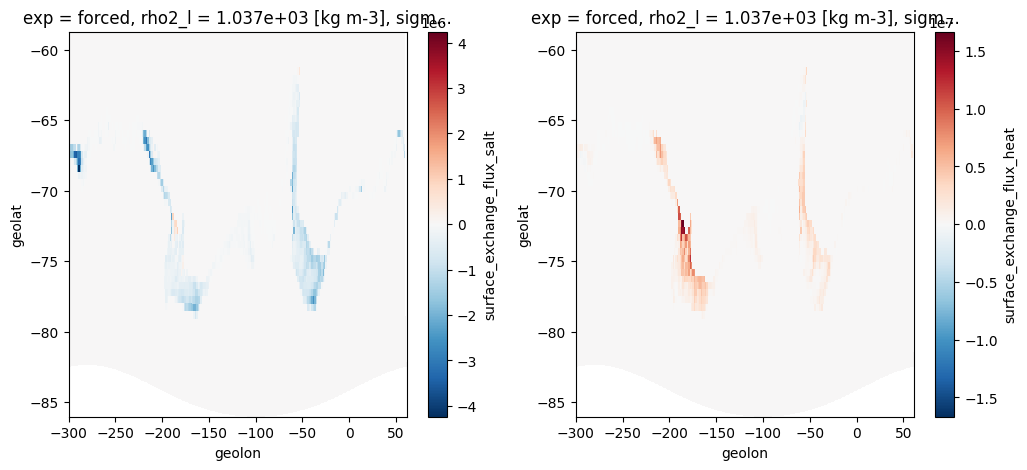

In [9]:
sigma = 36.974

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
wmts_ds.surface_exchange_flux_salt.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l_target = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[0])
wmts_ds.surface_exchange_flux_heat.isel(exp = 0).mean("year").sel(
                                                                  sigma2_l_target = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[1])

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
wmts_ds.isel(exp = 1).mean("year").surface_exchange_flux_salt.sel(sigma2_l_target = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[0])
wmts_ds.isel(exp = 1).mean("year").surface_exchange_flux_heat.sel(sigma2_l_target = sigma, method = "nearest").plot(x = "geolon", y = "geolat", ax = ax[1])